# 04. モニタリング判定基準の検証

## 目的

03では、Pen間差が急拡大した候補について、
候補日のPen間差の50%以上がその後3日間維持された場合に
継続的な変化（Persistent）と判定した。

しかし、50%という基準は探索的に設定したものであり、
判定結果が基準値にどの程度左右されるかは確認できていない。

本分析では、継続判定の基準を30%・50%・70%・90%に変更し、
判定結果を比較することで、判定ルールの感度を検証する。

In [1]:
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

PROJECT_ROOT = Path("..")

trial1 = pd.read_csv(
    PROJECT_ROOT / "data/interim/trial1_daily_quality_summary.csv",
    parse_dates=["date"]
)

trial2 = pd.read_csv(
    PROJECT_ROOT / "data/interim/trial2_daily_quality_summary.csv",
    parse_dates=["date"]
)

trial1["trial"] = "Trial 1"
trial2["trial"] = "Trial 2"

daily = pd.concat(
    [trial1, trial2],
    ignore_index=True
)

display(daily.head())

,date,pen,count,min_mass,median_mass,max_mass,over_10kg,trial
0,2019-06-19,1,546957,-0.43,-0.30,82.15,1166,Trial 1
1,2019-06-19,2,546949,-0.37,-0.22,-0.13,0,Trial 1
2,2019-06-19,3,546539,-0.52,-0.27,-0.05,0,Trial 1
3,2019-06-20,1,789613,-0.47,-0.34,-0.10,0,Trial 1
4,2019-06-20,2,789672,-0.41,-0.25,-0.08,0,Trial 1


In [2]:
# 日ごとのPen間差を計算
pen_spread = (
    daily.groupby(["trial", "date"])
    .agg(
        min_pen_mass=("median_mass", "min"),
        max_pen_mass=("median_mass", "max"),
        pen_count=("pen", "nunique")
    )
    .reset_index()
    .sort_values(["trial", "date"])
)

pen_spread["pen_spread"] = (
    pen_spread["max_pen_mass"] - pen_spread["min_pen_mass"]
)

# Trial開始日からの日数
pen_spread["day"] = (
    pen_spread.groupby("trial")["date"]
    .transform(lambda x: (x - x.min()).dt.days + 1)
)

# Pen間差の前日変化量
pen_spread["spread_change"] = (
    pen_spread.groupby("trial")["pen_spread"].diff()
)

# Trialごとに95パーセンタイルを計算
spread_thresholds = (
    pen_spread.groupby("trial")["spread_change"]
    .quantile(0.95)
)

# 急拡大候補を抽出
pen_spread["spread_threshold"] = (
    pen_spread["trial"].map(spread_thresholds)
)

pen_spread["rapid_spread"] = (
    pen_spread["spread_change"] >= pen_spread["spread_threshold"]
)

rapid_candidates = (
    pen_spread[pen_spread["rapid_spread"]]
    [["trial", "date", "day", "pen_spread", "spread_change"]]
    .reset_index(drop=True)
)

display(rapid_candidates)

,trial,date,day,pen_spread,spread_change
0,Trial 1,2019-06-27,9,28.150,27.070
1,Trial 1,2019-07-03,15,32.540,25.510
2,Trial 2,2019-10-11,33,9.520,4.910
3,Trial 2,2019-10-14,36,14.165,6.275


In [3]:
# 比較する継続判定基準
threshold_rates = [0.3, 0.5, 0.7, 0.9]

results = []

for _, candidate in rapid_candidates.iterrows():
    trial = candidate["trial"]
    candidate_day = candidate["day"]
    candidate_spread = candidate["pen_spread"]

    # 候補日の翌日から3日間
    after = pen_spread[
        (pen_spread["trial"] == trial) &
        (pen_spread["day"] > candidate_day) &
        (pen_spread["day"] <= candidate_day + 3)
    ]

    for rate in threshold_rates:
        threshold = candidate_spread * rate

        if len(after) < 3:
            classification = "Insufficient data"
        elif (after["pen_spread"] >= threshold).all():
            classification = "Persistent"
        else:
            classification = "Temporary"

        results.append({
            "trial": trial,
            "day": candidate_day,
            "threshold_rate": rate,
            "threshold_kg": threshold,
            "classification": classification
        })

validation_results = pd.DataFrame(results)

# 判定結果を比較しやすい表に変換
comparison = validation_results.pivot(
    index=["trial", "day"],
    columns="threshold_rate",
    values="classification"
)

comparison.columns = ["30%", "50%", "70%", "90%"]

display(comparison)

30%                50%                70%  \
trial   day                                                            
Trial 1 9            Temporary          Temporary          Temporary   
        15          Persistent         Persistent         Persistent   
Trial 2 33          Persistent         Persistent         Persistent   
        36   Insufficient data  Insufficient data  Insufficient data   

                           90%  
trial   day                     
Trial 1 9            Temporary  
        15          Persistent  
Trial 2 33           Temporary  
        36   Insufficient data

## 判定基準の比較結果

継続判定の基準を30%・50%・70%・90%に変更し、
急拡大候補4件の判定結果を比較した。

Trial 1のDay 9はすべての基準でTemporary、
Day 15はすべての基準でPersistentとなった。

一方、Trial 2のDay 33は30%・50%・70%ではPersistent、
90%ではTemporaryとなり、判定基準によって結果が変化した。

Trial 2のDay 36は追跡データが不足しているため、
すべての基準でInsufficient dataとなった。

### 考察

今回の比較から、判定結果が基準値の変更に対して
安定している候補と、基準値に依存する候補が存在することが分かった。

ただし、今回の分析では正解となる異常ラベルが存在しないため、
どの判定基準が最も適切かを判断することはできない。

今後は、判定基準の設定根拠や、実際の飼育状況との関連を
検証する必要がある。

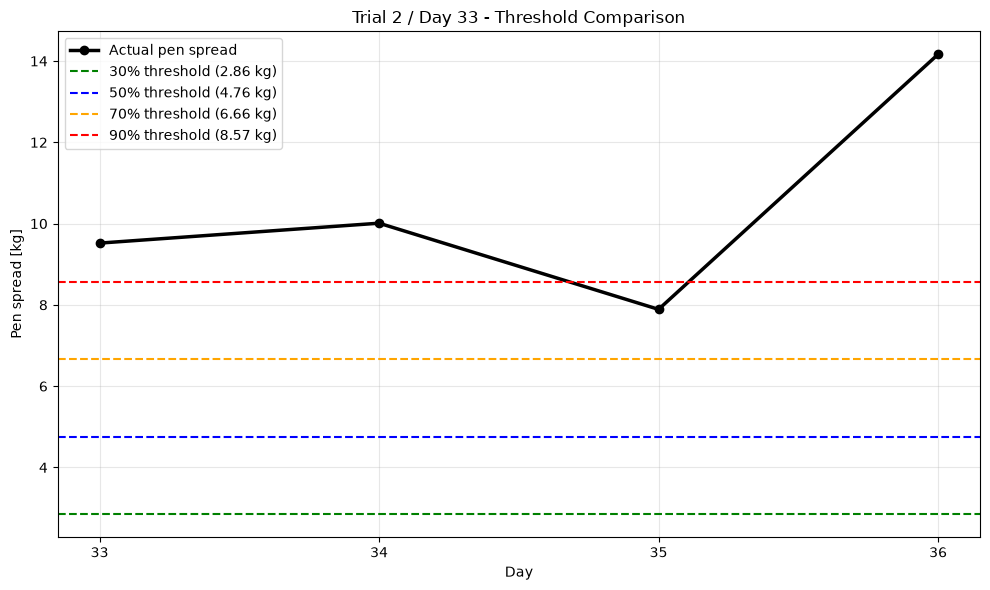

In [5]:
# Trial 2 / Day 33 のデータを取得
trial = "Trial 2"
candidate_day = 33

candidate = rapid_candidates[
    (rapid_candidates["trial"] == trial) &
    (rapid_candidates["day"] == candidate_day)
].iloc[0]

candidate_spread = candidate["pen_spread"]

# 候補日から3日後まで
plot_data = pen_spread[
    (pen_spread["trial"] == trial) &
    (pen_spread["day"].between(candidate_day, candidate_day + 3))
]

plt.figure(figsize=(10, 6))

# 実際のPen間差
plt.plot(
    plot_data["day"],
    plot_data["pen_spread"],
    marker="o",
    color="black",
    linewidth=2.5,
    label="Actual pen spread"
)

# 4種類の判定基準
colors = ["green", "blue", "orange", "red"]

for rate, color in zip(threshold_rates, colors):
    threshold = candidate_spread * rate

    plt.axhline(
        y=threshold,
        color=color,
        linestyle="--",
        label=f"{int(rate * 100)}% threshold ({threshold:.2f} kg)"
    )

plt.title("Trial 2 / Day 33 - Threshold Comparison")
plt.xlabel("Day")
plt.ylabel("Pen spread [kg]")
plt.xticks(plot_data["day"])
plt.grid(alpha=0.3)
plt.legend()
plt.tight_layout()

image_dir = PROJECT_ROOT / "images"
image_dir.mkdir(parents=True, exist_ok=True)

plt.savefig(
    image_dir / "trial2_day33_threshold_comparison.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

## 分析結果と考察

### 1. 判定基準の比較結果

継続判定の基準を30%・50%・70%・90%に変更し、
急拡大候補4件の判定結果を比較した。

- Trial 1 / Day 9：すべてTemporary
- Trial 1 / Day 15：すべてPersistent
- Trial 2 / Day 33：30〜70%はPersistent、90%はTemporary
- Trial 2 / Day 36：すべてInsufficient data

### 2. 判定基準による影響

Trial 2のDay 33では、Day 35のPen間差が7.89kgとなり、
90%の基準値8.57kgを下回った。

このため、90%の基準ではTemporaryと判定された。

一方、30〜70%の基準では3日間とも基準値を上回り、
Persistentと判定された。

### 3. 考察

今回の比較から、判定基準を変更しても結果が安定している候補と、
基準値によって判定が変わる候補が存在することが分かった。

特に厳しい基準では、一時的なPen間差の縮小によって
継続判定が変わる可能性がある。

ただし、今回の基準は探索的に設定したものであり、
正解となる異常ラベルも存在しないため、
どの基準が最適かは判断できない。

また、プラットフォーム荷重の変化は鶏の健康異常を
直接示すものではない。

今後は、判定基準の妥当性や実際の計測条件との関連を
検証する必要がある。